In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame =False)

In [5]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [6]:
X,y = mnist['data'], mnist['target']

In [8]:
X.shape

(70000, 784)

In [9]:
y.shape

(70000,)

In [13]:
X_train,X_test,y_train,y_test = X[:60000],X[60000:],y[:60000],y[60000:]

In [18]:
from sklearn.model_selection import RandomizedSearchCV 
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd 


In [14]:
rs = RandomizedSearchCV(KNeighborsClassifier(algorithm='auto'),{
    'weights': ['uniform', 'distance'],
    'n_neighbors': [3, 4, 5]
},
 cv=5,
 return_train_score = False,
 n_iter=2
)


In [15]:
rs.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(), n_iter=2,
                   param_distributions={'n_neighbors': [3, 4, 5],
                                        'weights': ['uniform', 'distance']})

In [22]:
pd.DataFrame(rs.cv_results_)[['mean_test_score','param_weights','param_n_neighbors']]

,mean_test_score,param_weights,param_n_neighbors
0,0.971617,distance,4
1,0.970067,uniform,3


In [23]:
rs.best_params_

{'weights': 'distance', 'n_neighbors': 4}

In [24]:
rs.best_score_

0.9716166666666666

In [25]:
from sklearn.metrics import accuracy_score

y_pred = rs.predict(X_test)
accuracy_score(y_test, y_pred)

0.9714

In [27]:
some_digit = X_test[250]
some_digit_image = some_digit.reshape(28, 28)

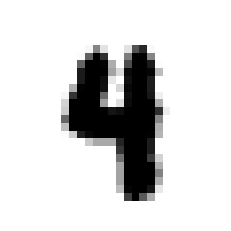

In [30]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.imshow(some_digit_image,cmap=mpl.cm.binary)
plt.axis("off")

plt.show()

In [31]:
y_test[250]

'4'

(10000,)

In [38]:
from sklearn.metrics import confusion_matrix

conf_mx = confusion_matrix(y_test, y_pred)
conf_mx

array([[ 973,    1,    1,    0,    0,    1,    3,    1,    0,    0],
       [   0, 1132,    2,    0,    0,    0,    1,    0,    0,    0],
       [  10,    5,  995,    2,    1,    0,    0,   16,    3,    0],
       [   0,    1,    3,  974,    1,   14,    1,    7,    4,    5],
       [   1,    5,    0,    0,  950,    0,    4,    3,    0,   19],
       [   4,    0,    0,    9,    2,  862,    7,    1,    3,    4],
       [   4,    2,    0,    0,    3,    3,  946,    0,    0,    0],
       [   0,   17,    4,    0,    3,    0,    0,  994,    0,   10],
       [   5,    2,    4,   14,    5,   11,    4,    4,  920,    5],
       [   3,    4,    2,    7,    9,    4,    1,   10,    1,  968]],
      dtype=int64)

In [39]:
#FUNKCJA ZAPOŻYCZONA Z https://github.com/ageron/handson-ml2
def plot_confusion_matrix(matrix):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111)
    cax = ax.matshow(matrix)
    fig.colorbar(cax)

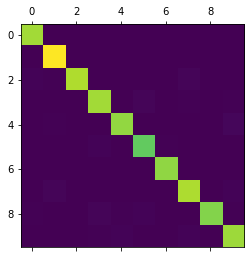

In [40]:
plt.matshow(conf_mx)
plt.show()